# Analyze Evals — question-first

This notebook does **no agent runs**. It loads every persisted run from `data/eval/runs/`
(written by `scripts/evals.ipynb` via `evals.store`) and answers questions about the data.
Each section is one question: the code computes the evidence, the last line prints the answer.

**Questions**

1. Which model is the most accurate?
2. Which model is the cheapest?
3. Which model is the fastest?
4. Which model is the best overall (cost × quality × speed)?
5. What should `max_tool_calls` be?
6. How do the benchmarks compare?
7. Which tools are most important?
8. Which cards are the worst — everywhere vs per-model?
9. **Why** do cards fail? (aggregated failure modes + optional LLM clustering)
10. Does the BM25+RRF hybrid retriever beat dense `card_rag`? (Task 6)

Data shaping lives in `evals.analysis` (unit-tested); this notebook is a thin driver.
Only section 9's last cell calls an LLM, and it is off by default.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))  # make src/ importable from scripts/

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from evals import analysis, store, viz

pd.set_option("display.max_colwidth", 90)
pd.set_option("display.width", 200)

payloads = store.load_runs()
runs = analysis.runs_frame(payloads)
rows = analysis.rows_frame(payloads)

print(f"{len(runs)} runs, {len(rows)} card-rows, models: {sorted(runs.model_short.unique())}")
runs[
    [
        "run",
        "benchmark",
        "model_short",
        "max_tool_calls",
        "enabled_tools",
        "is_baseline",
        "cases",
        "quality",
        "mean_cost_usd",
        "p50_latency_ms",
    ]
].round(3)

21 runs, 1530 card-rows, models: ['gemma-4-31b', 'haiku-4-5', 'opus-4-8', 'sonnet-5']


,run,benchmark,model_short,max_tool_calls,enabled_tools,is_baseline,cases,quality,mean_cost_usd,p50_latency_ms
0,20260714-161721 sonnet - eval,eval,sonnet-5,NaN,NaN,True,42,0.801,0.153,15681.714
1,20260714-162351 sonnet - seed,seed,sonnet-5,NaN,NaN,True,69,0.793,0.185,24020.279
2,20260714-170328 sonnet - eval_hard,eval_hard,sonnet-5,NaN,NaN,True,25,0.890,0.222,26242.007
3,20260714-171335 haiku - eval,eval,haiku-4-5,NaN,NaN,True,42,0.742,0.033,9172.193
4,20260714-171642 haiku - seed,seed,haiku-4-5,NaN,NaN,True,69,0.685,0.048,11635.929
5,20260714-172238 haiku - eval_hard,eval_hard,haiku-4-5,NaN,NaN,True,25,0.789,0.038,11449.830
6,20260714-172637 opus - eval,eval,opus-4-8,NaN,NaN,True,42,0.808,0.135,10794.839
7,20260714-173730 opus - seed,seed,opus-4-8,NaN,NaN,True,69,0.776,0.173,13927.346
8,20260714-174357 opus - eval_hard,eval_hard,opus-4-8,NaN,NaN,True,25,0.801,0.176,12749.773
9,20260714-174948 gemma - eval,eval,gemma-4-31b,NaN,NaN,True,42,0.522,0.005,3213.093


## Comparability guardrail

Two kinds of runs live in `runs/`:

- **baseline** — production toolbox, default step cap (`is_baseline`). Only these are
  apples-to-apples for *model* comparisons (Q1–Q4, Q6, Q8).
- **experiments** — the `max_tool_calls` sweep and tool-ablation runs (haiku on `eval_hard`).
  They answer Q5 and Q7 and must be excluded everywhere else.

`quality` is the composite: the mean of the seven 0–1 quality scorers
(`viz.QUALITY_METRICS` — judge metrics + sandbox behavior + executability + did_something).
All of this is n=1 sample per card, so treat small deltas (±0.03 on a 25-card benchmark
is one card) as noise, not signal.

In [2]:
from matplotlib.colors import LinearSegmentedColormap

# Fixed entity colors (dataviz: color follows the entity, assigned in fixed order, never cycled)
MODEL_ORDER = ["sonnet-5", "haiku-4-5", "opus-4-8", "gemma-4-31b"]
MODEL_ORDER += sorted(set(runs.model_short) - set(MODEL_ORDER))  # future models get the next slots
MODEL_COLORS = {m: viz.SERIES_COLORS[i % len(viz.SERIES_COLORS)] for i, m in enumerate(MODEL_ORDER)}
BENCH_ORDER = [b for b in ["eval", "eval_hard", "seed"] if b in set(runs.benchmark)]

MUTED, INK, GRID = "#898781", "#0b0b0b", "#e1e0d9"
# dataviz reference sequential blue ramp (steps 100→700), light = low
SEQ_BLUES = [
    "#cde2fb",
    "#b7d3f6",
    "#9ec5f4",
    "#86b6ef",
    "#6da7ec",
    "#5598e7",
    "#3987e5",
    "#2a78d6",
    "#256abf",
    "#1c5cab",
    "#184f95",
    "#104281",
    "#0d366b",
]
SEQ_CMAP = LinearSegmentedColormap.from_list("seq_blue", SEQ_BLUES)


def style(ax):
    viz._style_axes(ax)


def grouped_bars(ax, index_labels, series, width_total=0.8):
    # series: list of (name, color, values) — one bar cluster per index label
    x = np.arange(len(index_labels))
    w = width_total / max(1, len(series))
    for i, (name, color, vals) in enumerate(series):
        vals = np.asarray([np.nan if v is None else v for v in vals], dtype=float)
        mask = ~np.isnan(vals)
        ax.bar(x[mask] + i * w, vals[mask], w * 0.92, label=name, color=color)
    ax.set_xticks(x + w * (len(series) - 1) / 2)
    ax.set_xticklabels(index_labels)
    style(ax)


def answer(text):
    print(f"\n\u25b6 ANSWER: {text}")


baseline = runs[runs.is_baseline].copy()
base_rows = rows[rows.is_baseline].copy()
# benchmarks every model has run — fair ground for cross-model aggregates
common_benches = [
    b for b in BENCH_ORDER if set(baseline[baseline.benchmark == b].model_short) == set(baseline.model_short)
]
print("baseline runs:", len(baseline), "| benchmarks shared by all models:", common_benches)

baseline runs: 11 | benchmarks shared by all models: ['eval', 'eval_hard']


## Q1 — Which model is the most accurate?

Composite quality per model per benchmark (baseline runs only), then the per-metric
breakdown to see *where* a model wins or loses. Ranking uses only the benchmarks
every model has run, so a model can't win by skipping the hard set.

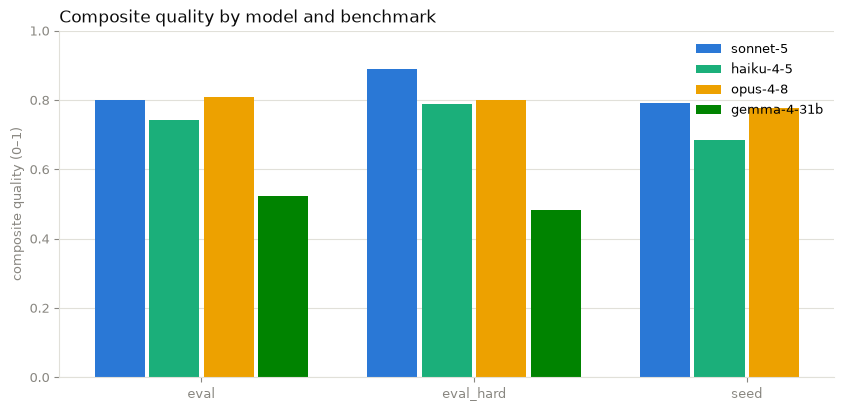

,intent_match,target_accuracy,persistence_accuracy,magnitude_sign,sandbox_behavior,executability,did_something,quality
model_short,,,,,,,,
sonnet-5,0.913,0.859,0.870,0.971,0.531,0.964,0.809,0.845
opus-4-8,0.839,0.807,0.842,0.912,0.510,0.916,0.804,0.804
haiku-4-5,0.840,0.765,0.770,0.877,0.432,0.869,0.809,0.766
gemma-4-31b,0.503,0.488,0.485,0.541,0.372,0.681,0.450,0.503



▶ ANSWER: most accurate: sonnet-5 (0.845 composite across ['eval', 'eval_hard']); opus-4-8 (0.804), then haiku-4-5 (0.766), then gemma-4-31b (0.503)


In [3]:
fig, ax = plt.subplots(figsize=(10, 4.5))
series = []
for m in [m for m in MODEL_ORDER if m in set(baseline.model_short)]:
    sub = baseline[baseline.model_short == m].set_index("benchmark")["quality"]
    series.append((m, MODEL_COLORS[m], [sub.get(b) for b in BENCH_ORDER]))
grouped_bars(ax, BENCH_ORDER, series)
ax.set_ylim(0, 1)
ax.set_ylabel("composite quality (0\u20131)", color=MUTED, fontsize=9)
ax.set_title("Composite quality by model and benchmark", color=INK, fontsize=12, loc="left")
ax.legend(frameon=False, fontsize=9)
plt.show()

per_metric = (
    baseline[baseline.benchmark.isin(common_benches)]
    .groupby("model_short")[viz.QUALITY_METRICS + ["quality"]]
    .mean()
    .sort_values("quality", ascending=False)
    .round(3)
)
display(per_metric)

ranked = per_metric["quality"]
answer(
    f"most accurate: {ranked.index[0]} ({ranked.iloc[0]:.3f} composite across {common_benches}); "
    + ", then ".join(f"{m} ({v:.3f})" for m, v in ranked.iloc[1:].items())
)

## Q2 — Which model is the cheapest?

Mean cost per card (what you'd pay per card played), on the shared benchmarks.
Total spend so far is included for the budget conversation.

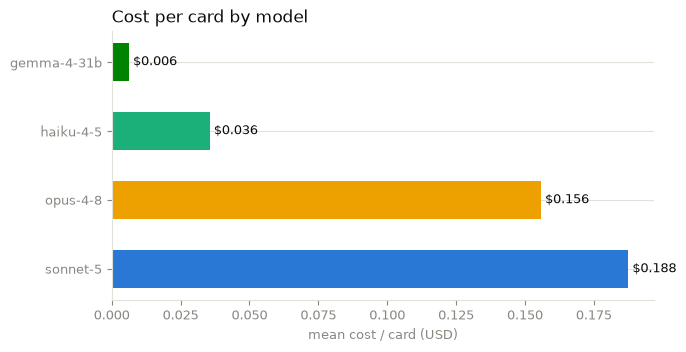

,mean_cost_usd,total_cost_usd,mean_total_tokens
model_short,,,
gemma-4-31b,0.0063,0.3978,35703.5757
haiku-4-5,0.0356,2.3392,30903.8986
opus-4-8,0.1558,10.0943,27528.6705
sonnet-5,0.1875,11.9831,55033.4124



▶ ANSWER: cheapest: gemma-4-31b ($0.006/card) — 30× cheaper than sonnet-5 ($0.188/card)


In [4]:
cost = (
    baseline[baseline.benchmark.isin(common_benches)]
    .groupby("model_short")
    .agg(
        mean_cost_usd=("mean_cost_usd", "mean"),
        total_cost_usd=("total_cost_usd", "sum"),
        mean_total_tokens=("mean_total_tokens", "mean"),
    )
    .sort_values("mean_cost_usd")
)

fig, ax = plt.subplots(figsize=(7, 3.5))
order = cost.index.tolist()
ax.barh(range(len(order)), cost.mean_cost_usd, color=[MODEL_COLORS[m] for m in order], height=0.55)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.invert_yaxis()
for i, v in enumerate(cost.mean_cost_usd):
    ax.text(v, i, f" ${v:.3f}", va="center", color=INK, fontsize=9)
ax.set_xlabel("mean cost / card (USD)", color=MUTED, fontsize=9)
ax.set_title("Cost per card by model", color=INK, fontsize=12, loc="left")
style(ax)
plt.show()

display(cost.round(4))
ratio = cost.mean_cost_usd.iloc[-1] / cost.mean_cost_usd.iloc[0]
answer(
    f"cheapest: {cost.index[0]} (${cost.mean_cost_usd.iloc[0]:.3f}/card) \u2014 "
    f"{ratio:.0f}\u00d7 cheaper than {cost.index[-1]} (${cost.mean_cost_usd.iloc[-1]:.3f}/card)"
)

## Q3 — Which model is the fastest?

Latency is what a table of humans feels while a card resolves. p50 is the typical card,
p95 is the card everyone groans about — both matter, each gets its own panel (one measure per axis).

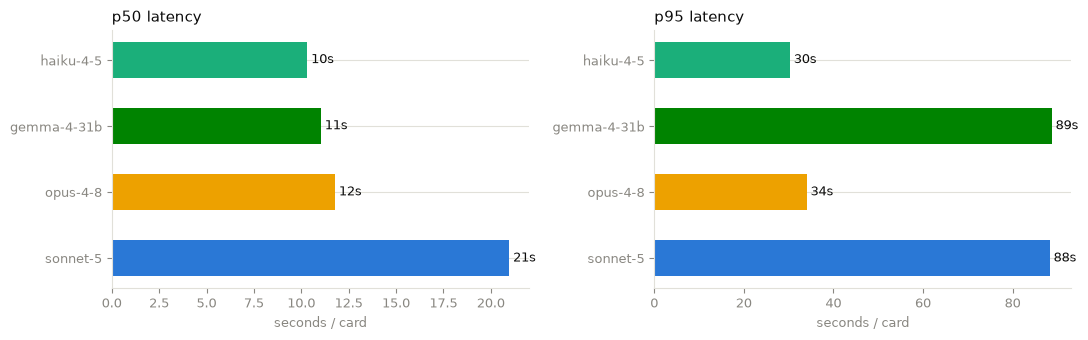


▶ ANSWER: fastest: haiku-4-5 (p50 10s/card); slowest: sonnet-5 (p50 21s, p95 88s — that's the groan)


In [5]:
lat = (
    baseline[baseline.benchmark.isin(common_benches)]
    .groupby("model_short")[["p50_latency_ms", "p95_latency_ms"]]
    .mean()
    .sort_values("p50_latency_ms")
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, col, title in zip(axes, ["p50_latency_ms", "p95_latency_ms"], ["p50 latency", "p95 latency"]):
    vals = lat[col] / 1000
    ax.barh(range(len(lat)), vals, color=[MODEL_COLORS[m] for m in lat.index], height=0.55)
    ax.set_yticks(range(len(lat)))
    ax.set_yticklabels(lat.index)
    ax.invert_yaxis()
    for i, v in enumerate(vals):
        ax.text(v, i, f" {v:.0f}s", va="center", color=INK, fontsize=9)
    ax.set_title(title, color=INK, fontsize=11, loc="left")
    ax.set_xlabel("seconds / card", color=MUTED, fontsize=9)
    style(ax)
plt.tight_layout()
plt.show()

answer(
    f"fastest: {lat.index[0]} (p50 {lat.p50_latency_ms.iloc[0] / 1000:.0f}s/card); "
    f"slowest: {lat.index[-1]} (p50 {lat.p50_latency_ms.iloc[-1] / 1000:.0f}s, "
    f"p95 {lat.p95_latency_ms.iloc[-1] / 1000:.0f}s \u2014 that's the groan)"
)

## Q4 — Which model is the best overall?

Cost vs quality scatter (down-right is bad, up-left is good), plus a rank-sum across
quality (higher better), cost and p50 latency (lower better) on the shared benchmarks.
Rank-sum is deliberately crude — it weights the three equally; reweight to taste.

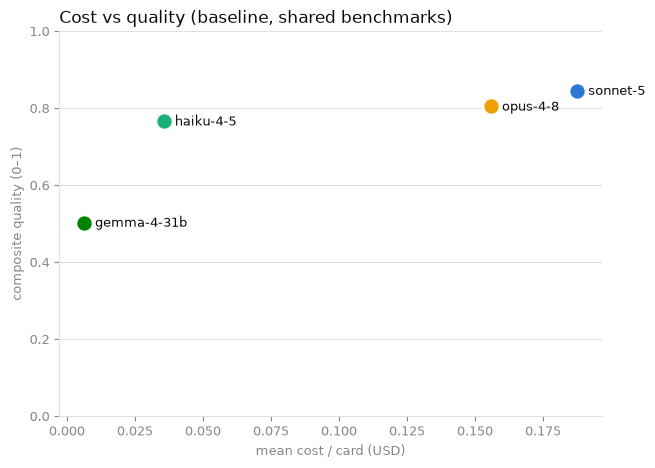

,quality,cost,p50,rank_sum
model_short,,,,
haiku-4-5,0.766,0.036,10311.011,6.0
gemma-4-31b,0.503,0.006,11029.926,7.0
opus-4-8,0.804,0.156,11772.306,8.0
sonnet-5,0.845,0.188,20961.860,9.0



▶ ANSWER: best overall by rank-sum: haiku-4-5; all models sit on the cost–quality frontier — more money buys more quality, pick by budget


In [6]:
perf = (
    baseline[baseline.benchmark.isin(common_benches)]
    .groupby("model_short")
    .agg(quality=("quality", "mean"), cost=("mean_cost_usd", "mean"), p50=("p50_latency_ms", "mean"))
)
perf["rank_sum"] = perf.quality.rank(ascending=False) + perf.cost.rank() + perf.p50.rank()
perf = perf.sort_values("rank_sum")

fig, ax = plt.subplots(figsize=(7, 5))
for m, row in perf.iterrows():
    ax.scatter(row.cost, row.quality, s=140, color=MODEL_COLORS[m], zorder=3, edgecolor="#fcfcfb", linewidth=1.5)
    ax.annotate(m, (row.cost, row.quality), xytext=(8, -3), textcoords="offset points", color=INK, fontsize=9)
ax.set_xlabel("mean cost / card (USD)", color=MUTED, fontsize=9)
ax.set_ylabel("composite quality (0\u20131)", color=MUTED, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title("Cost vs quality (baseline, shared benchmarks)", color=INK, fontsize=12, loc="left")
style(ax)
plt.show()

display(perf.round(3))

# Pareto frontier: models no other model beats on BOTH cost and quality
dominated = {
    m
    for m in perf.index
    for o in perf.index
    if o != m
    and perf.loc[o, "cost"] <= perf.loc[m, "cost"]
    and perf.loc[o, "quality"] >= perf.loc[m, "quality"]
    and (perf.loc[o, "cost"] < perf.loc[m, "cost"] or perf.loc[o, "quality"] > perf.loc[m, "quality"])
}
frontier = [m for m in perf.sort_values("cost").index if m not in dominated]
frontier_note = (
    f"only {frontier} are on the cost\u2013quality frontier \u2014 the rest are strictly beaten"
    if dominated
    else "all models sit on the cost\u2013quality frontier \u2014 more money buys more quality, pick by budget"
)
answer(f"best overall by rank-sum: {perf.index[0]}; {frontier_note}")

## Q5 — What should `max_tool_calls` be?

The sweep: haiku on `eval_hard` at caps 6 / 12 / 18 / default (24), full toolbox.

`max_tool_calls` is a **graph-step** cap (`agent.runtime`: ~2 steps per tool round-trip
plus the final answer), so the pressure proxy is `2·tool_calls + 2 ≥ cap`, and the hard
failure it causes is the forced-fallback answer (`agent_error`).

**Reading noise:** n=1 sample per card. Caps 18 and 24 barely bind (pressure ≤ 8%), so the
quality gap *between them* is a live estimate of the run-to-run noise floor — deltas smaller
than that gap are not signal.

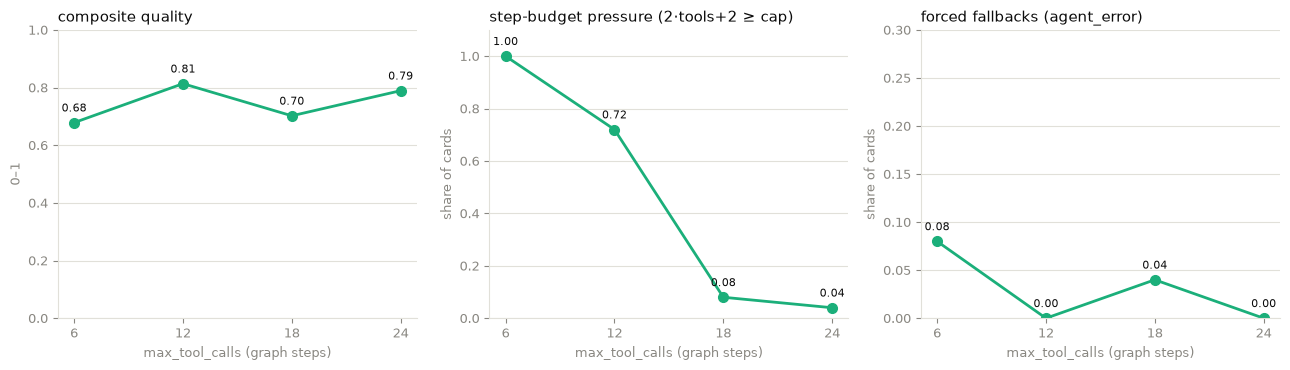

,run,quality,mean_tool_calls,mean_cost_usd,p50_latency_ms,agent_error_rate
cap,,,,,,
6,20260714-181828 haiku - eval_hard - maxtools=6,0.678,3.60,0.019,10430.958,0.08
12,20260714-181546 haiku - eval_hard - maxtools=12,0.814,5.20,0.036,13321.294,0.00
18,20260714-182506 haiku - eval_hard - maxtools=18,0.702,5.20,0.040,12760.879,0.04
24,20260714-172238 haiku - eval_hard,0.789,4.96,0.038,11449.830,0.00



▶ ANSWER: barely-binding caps [18, 24] differ by 0.09 composite — the n=1 noise floor. cap=6 truncates every card (pressure 100%) and forces fallbacks on 8%; mean tool use stays ~5 calls whatever the cap, so a generous cap costs nothing on average — it only bounds the tail. Smallest cap with zero forced fallbacks and quality within the noise floor of the best: 12. Recommendation: 12 (or keep the default 24 if tail latency is fine); rerun with n_samples≥3 before hard-coding.


In [7]:
sweep = runs[(runs.model_short == "haiku-4-5") & (runs.benchmark == "eval_hard") & runs.enabled_tools.isna()].copy()
sweep["cap"] = sweep.max_tool_calls.fillna(24).astype(int)  # None = production default (24)
sweep = sweep.sort_values("cap")

sweep_rows = rows[rows.run.isin(sweep.run)].copy()
sweep_rows["cap"] = sweep_rows.max_tool_calls.fillna(24).astype(int)
pressure = sweep_rows.groupby("cap").apply(lambda g: (2 * g.tool_calls + 2 >= g.name).mean(), include_groups=False)
fallback = sweep_rows.groupby("cap").agent_error.mean()

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
panels = [
    ("composite quality", sweep.set_index("cap").quality, "0\u20131", (0, 1)),
    ("step-budget pressure (2\u00b7tools+2 \u2265 cap)", pressure, "share of cards", (0, 1.1)),
    ("forced fallbacks (agent_error)", fallback, "share of cards", (0, 0.3)),
]
for ax, (title, s, unit, ylim) in zip(axes, panels):
    ax.plot(s.index, s.values, marker="o", markersize=7, linewidth=2, color=MODEL_COLORS["haiku-4-5"])
    for x, y in s.items():
        ax.annotate(f"{y:.2f}", (x, y), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8, color=INK)
    ax.set_xticks(s.index.tolist())
    ax.set_xlabel("max_tool_calls (graph steps)", color=MUTED, fontsize=9)
    ax.set_ylabel(unit, color=MUTED, fontsize=9)
    if ylim:
        ax.set_ylim(*ylim)
    ax.set_title(title, color=INK, fontsize=11, loc="left")
    style(ax)
plt.tight_layout()
plt.show()

display(
    sweep[["run", "cap", "quality", "mean_tool_calls", "mean_cost_usd", "p50_latency_ms", "agent_error_rate"]]
    .round(3)
    .set_index("cap")
)

q = sweep.set_index("cap").quality
loose = pressure[pressure <= 0.2].index  # caps that barely bind
noise = float(q.loc[loose].max() - q.loc[loose].min()) if len(loose) >= 2 else 0.05
candidates = q[(fallback.reindex(q.index).fillna(0) == 0) & (q >= q.max() - noise)]
rec = int(candidates.index.min()) if len(candidates) else int(q.idxmax())
answer(
    f"barely-binding caps {sorted(loose)} differ by {noise:.2f} composite \u2014 the n=1 noise floor. "
    f"cap=6 truncates every card (pressure {pressure.get(6, 0):.0%}) and forces fallbacks on "
    f"{fallback.get(6, 0):.0%}; mean tool use stays ~{sweep.mean_tool_calls.mean():.0f} calls whatever the cap, "
    f"so a generous cap costs nothing on average \u2014 it only bounds the tail. "
    f"Smallest cap with zero forced fallbacks and quality within the noise floor of the best: {rec}. "
    f"Recommendation: {rec} (or keep the default 24 if tail latency is fine); rerun with n_samples\u22653 before hard-coding."
)

## Q6 — How do the benchmarks compare?

Same models, three card sets. Two things to read: how much harder `eval_hard` really is
(per-metric drop from `eval`), and whether `seed` is inflated — the RAG store contains the
seed cards' own canonicals, so `card_rag` can retrieve the answer key on that benchmark.

,intent_match,target_accuracy,persistence_accuracy,magnitude_sign,sandbox_behavior,executability,did_something,quality
benchmark,,,,,,,,
eval,0.759,0.675,0.683,0.843,0.409,0.875,0.786,0.718
eval_hard,0.788,0.785,0.801,0.808,0.513,0.840,0.650,0.741
seed,0.804,0.729,0.749,0.884,0.435,0.889,0.768,0.751


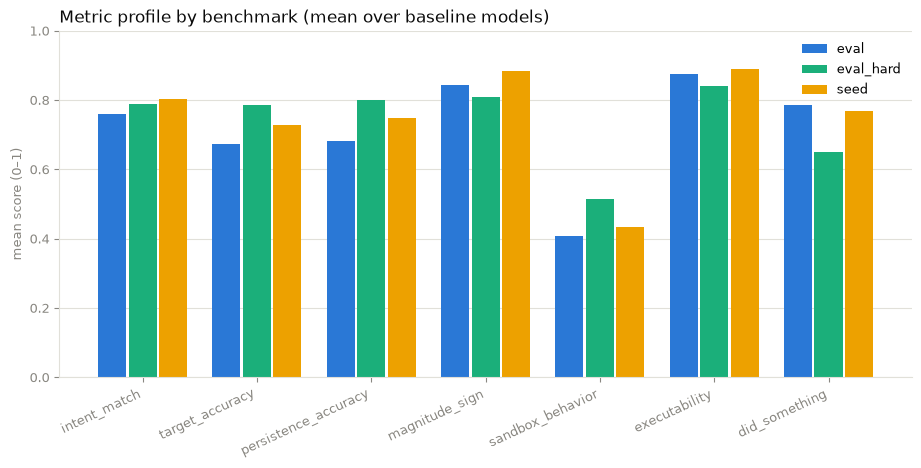


▶ ANSWER: eval_hard composite is +0.022 vs eval: NOT harder on the composite — the difficulty is per-metric, not overall. Biggest per-metric drop on eval_hard: did_something (−0.136) — hard cards produce more refusals/no-ops even when the reading is right. seed scores carry the RAG answer-key caveat — don't read seed as 'easier' or 'harder'.


In [8]:
bench_metrics = baseline.groupby("benchmark")[viz.QUALITY_METRICS + ["quality"]].mean().reindex(BENCH_ORDER)
display(bench_metrics.round(3))

fig, ax = plt.subplots(figsize=(11, 4.5))
bench_colors = dict(zip(BENCH_ORDER, viz.SERIES_COLORS))
series = [(b, bench_colors[b], bench_metrics.loc[b, viz.QUALITY_METRICS].tolist()) for b in BENCH_ORDER]
grouped_bars(ax, viz.QUALITY_METRICS, series)
ax.set_xticklabels(viz.QUALITY_METRICS, rotation=25, ha="right")
ax.set_ylim(0, 1)
ax.set_ylabel("mean score (0\u20131)", color=MUTED, fontsize=9)
ax.set_title("Metric profile by benchmark (mean over baseline models)", color=INK, fontsize=12, loc="left")
ax.legend(frameon=False, fontsize=9)
plt.show()

if {"eval", "eval_hard"} <= set(bench_metrics.index):
    hard_delta = bench_metrics.loc["eval_hard", "quality"] - bench_metrics.loc["eval", "quality"]
    drop = (
        bench_metrics.loc["eval", viz.QUALITY_METRICS] - bench_metrics.loc["eval_hard", viz.QUALITY_METRICS]
    ).sort_values(ascending=False)
    biggest = drop.index[0]
    verdict_txt = (
        "harder as intended"
        if hard_delta < -0.02
        else "NOT harder on the composite \u2014 the difficulty is per-metric, not overall"
    )
    answer(
        f"eval_hard composite is {hard_delta:+.3f} vs eval: {verdict_txt}. "
        f"Biggest per-metric drop on eval_hard: {biggest} (\u2212{drop.iloc[0]:.3f}) \u2014 hard cards "
        f"produce more refusals/no-ops even when the reading is right. "
        f"seed scores carry the RAG answer-key caveat \u2014 don't read seed as 'easier' or 'harder'."
    )

## Q7 — Which tools are most important?

Three lenses, weakest to strongest evidence:

1. **Usage mix** — where each model actually spends its calls (baseline runs).
2. **Used-vs-not quality** — per tool, mean row quality when the agent called it vs didn't.
   *Correlational*: hard cards trigger more tool use, so a low "used" score can mean
   "the tool attracts hard cards", not "the tool hurts".
3. **Ablations** — the causal lens: haiku/`eval_hard`/cap=12 with the full toolbox vs
   two restricted toolboxes. Fewer tools, same cap → the delta is the removed tools' value.

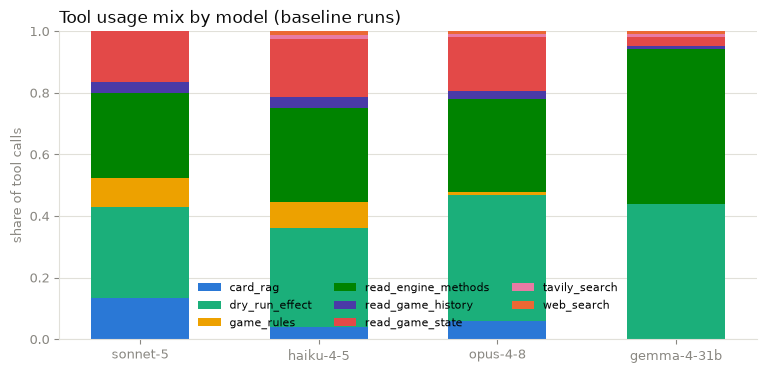

,rows_used,quality_when_used,quality_when_not
tool,,,
dry_run_effect,443,0.754,0.508
read_engine_methods,400,0.742,0.715
read_game_state,210,0.759,0.721
card_rag,95,0.774,0.728
game_rules,80,0.731,0.739
read_game_history,40,0.614,0.749
tavily_search,9,0.752,0.737
web_search,9,0.752,0.737


In [9]:
# 1. usage mix
usage = (
    base_rows.explode("per_tool")  # keys only
    .groupby(["model_short", "per_tool"])
    .size()
    .unstack(fill_value=0)
)
usage_share = usage.div(usage.sum(axis=1), axis=0).reindex([m for m in MODEL_ORDER if m in usage.index])
tools = usage_share.columns.tolist()
tool_colors = dict(zip(tools, viz.SERIES_COLORS))

fig, ax = plt.subplots(figsize=(9, 4))
bottom = np.zeros(len(usage_share))
for t in tools:
    ax.bar(range(len(usage_share)), usage_share[t], bottom=bottom, width=0.55, label=t, color=tool_colors[t])
    bottom += usage_share[t].values
ax.set_xticks(range(len(usage_share)))
ax.set_xticklabels(usage_share.index)
ax.set_ylabel("share of tool calls", color=MUTED, fontsize=9)
ax.set_title("Tool usage mix by model (baseline runs)", color=INK, fontsize=12, loc="left")
style(ax)
ax.legend(frameon=False, fontsize=8, ncol=3)
plt.show()

# 2. used-vs-not quality (correlational)
records = []
for t in tools:
    used = base_rows.per_tool.apply(lambda d, t=t: t in d)
    records.append(
        {
            "tool": t,
            "rows_used": int(used.sum()),
            "quality_when_used": base_rows[used].quality.mean(),
            "quality_when_not": base_rows[~used].quality.mean(),
        }
    )
display(pd.DataFrame(records).set_index("tool").round(3).sort_values("rows_used", ascending=False))

In [10]:
# 3. ablations — same model/benchmark/cap, different toolboxes
ablate = runs[(runs.model_short == "haiku-4-5") & (runs.benchmark == "eval_hard") & (runs.max_tool_calls == 12)].copy()
ablate["toolbox"] = ablate.enabled_tools.fillna("FULL toolbox")
cols = ["toolbox", "quality", "mean_tool_calls", "mean_cost_usd", "p50_latency_ms", "agent_error_rate"]
display(ablate[cols].round(3).sort_values("quality", ascending=False).set_index("toolbox"))

full = ablate[ablate.enabled_tools.isna()]
if len(full) and len(ablate) > 1:
    fq = full.quality.iloc[0]
    all_tools = set(usage.columns)
    deltas = {}
    for row in ablate.itertuples():
        if pd.isna(row.enabled_tools):
            continue
        removed = "+".join(sorted(all_tools - set(row.enabled_tools.split("+"))))
        deltas[f"\u2212{{{removed}}}"] = row.quality - fq
    answer(
        "quality delta vs full toolbox (haiku/eval_hard/cap=12), by tools REMOVED: "
        + "; ".join(f"{k}: {v:+.3f}" for k, v in sorted(deltas.items(), key=lambda kv: kv[1]))
        + ". Both ablations lose quality \u2014 the read tools earn their keep; the gap between the two "
        "ablations is what read_engine_methods alone buys back. Usage says dry_run_effect is the "
        "workhorse everywhere. Rerun with n_samples\u22653 before dropping anything."
    )

,quality,mean_tool_calls,mean_cost_usd,p50_latency_ms,agent_error_rate
toolbox,,,,,
FULL toolbox,0.814,5.20,0.036,13321.294,0.00
card_rag_hybrid+dry_run_effect+game_rules+mtg_lookup+read_engine_methods+read_game_history+read_game_state+recall_decisions+remember_decision+web_search+wish,0.801,4.68,0.034,12700.597,0.00
dry_run_effect+read_engine_methods+read_game_state,0.738,5.00,0.031,13948.471,0.08
dry_run_effect+read_game_state,0.533,5.20,0.029,14585.163,0.04



▶ ANSWER: quality delta vs full toolbox (haiku/eval_hard/cap=12), by tools REMOVED: −{card_rag+game_rules+read_engine_methods+read_game_history+tavily_search+web_search}: -0.280; −{card_rag+game_rules+read_game_history+tavily_search+web_search}: -0.076; −{card_rag+tavily_search}: -0.012. Both ablations lose quality — the read tools earn their keep; the gap between the two ablations is what read_engine_methods alone buys back. Usage says dry_run_effect is the workhorse everywhere. Rerun with n_samples≥3 before dropping anything.


## Q8 — Which cards are the worst?

Better than one run's bottom-10: aggregate every card **across all runs it appears in**.
`fail_rate` = share of runs where composite quality < 0.5; `models_failed` separates
"everyone fails this card" (a card/canonical problem) from "only model X fails it"
(a model problem). The heatmap shows the worst 25 shared-benchmark cards × models —
light = failing, dark = solid.

In [11]:
difficulty = analysis.card_difficulty(base_rows)
display(difficulty.head(15).round(3))

universal = difficulty[(difficulty.fail_rate >= 0.75) & (difficulty.runs >= 3)]
answer(
    f"{len(universal)} cards fail in \u226575% of runs \u2014 card/canonical problems, not model problems: "
    f"{universal.index.tolist()}"
)

,title,benchmark,runs,mean_quality,min_quality,fail_rate,models_failed,top_bucket
card_id,,,,,,,,
seed-filler-011,Time Warp,seed,3,0.062,0.000,1.000,"[haiku-4-5, opus-4-8, sonnet-5]",declared_invalid
hard-014,Grabby Hands,eval_hard,4,0.214,0.000,0.750,"[gemma-4-31b, haiku-4-5, opus-4-8]",declared_invalid
eval-041,Sticky Fingers,eval,4,0.214,0.000,0.750,"[gemma-4-31b, haiku-4-5, opus-4-8]",declared_invalid
seed-filler-032,Hot Potato,seed,3,0.286,0.000,0.667,"[haiku-4-5, opus-4-8]",behavior_mismatch
hard-015,Mirror Match,eval_hard,4,0.345,0.000,0.500,"[gemma-4-31b, opus-4-8]",declared_invalid
seed-filler-029,The Clone,seed,3,0.388,0.000,0.333,[haiku-4-5],no_op
eval-020,Score Doubler,eval,4,0.400,0.000,0.500,"[gemma-4-31b, sonnet-5]",behavior_mismatch
eval-027,Blank White Card,eval,4,0.404,0.271,0.750,"[gemma-4-31b, haiku-4-5, sonnet-5]",no_plan
hard-013,Nuh-Uh,eval_hard,4,0.414,0.000,0.500,"[gemma-4-31b, opus-4-8]",declared_invalid



▶ ANSWER: 6 cards fail in ≥75% of runs — card/canonical problems, not model problems: ['seed-filler-011', 'hard-014', 'eval-041', 'eval-027', 'eval-028', 'eval-012']


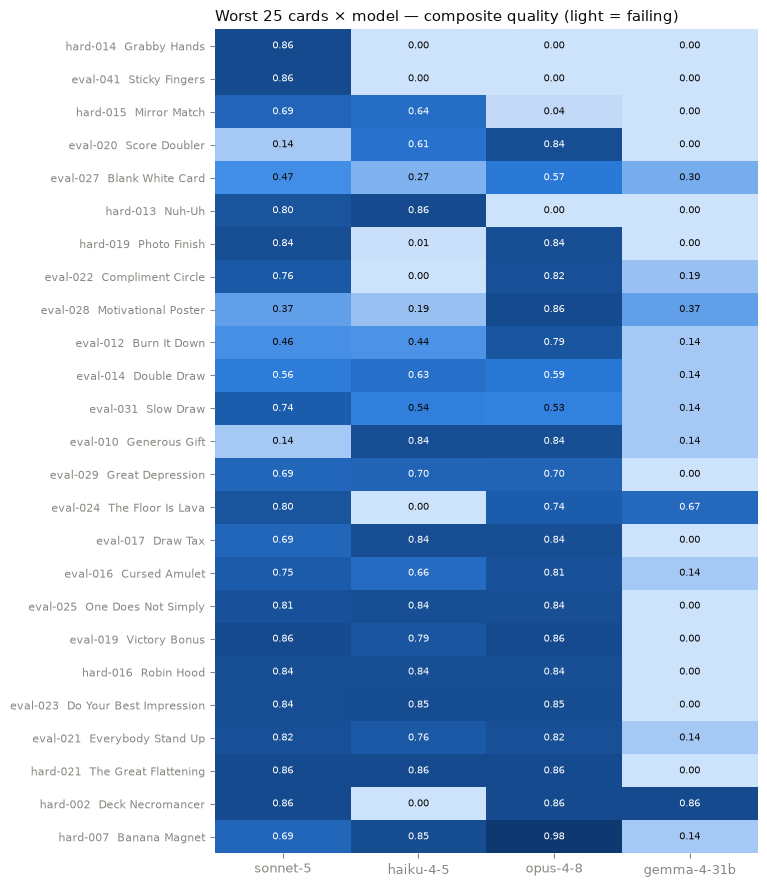

In [12]:
heat_rows = base_rows[base_rows.benchmark.isin(common_benches)]
pivot = analysis.quality_pivot(heat_rows).head(25)
models = [m for m in MODEL_ORDER if m in pivot.columns]
pivot = pivot[models]

fig, ax = plt.subplots(figsize=(7, 0.38 * len(pivot) + 1.2))
ax.imshow(pivot.values, cmap=SEQ_CMAP, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, fontsize=9)
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels([f"{cid}  {title[:28]}" for cid, title in pivot.index], fontsize=8)
for i in range(len(pivot)):
    for j in range(len(models)):
        v = pivot.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7, color="#ffffff" if v > 0.55 else INK)
ax.set_title(
    "Worst 25 cards \u00d7 model \u2014 composite quality (light = failing)", color=INK, fontsize=11, loc="left"
)
ax.tick_params(colors=MUTED)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.show()

## Q9 — Why do cards fail?

Every failing dimension is mapped to a named **failure bucket** (`analysis.FAILURE_BUCKETS`,
coarse → specific; a row can hit several). The buckets come from the actual reason strings
the scorers record, so counts are exact, not vibes:

| bucket | meaning |
|---|---|
| `agent_error` | agent crashed / hit a cap and emitted the fallback |
| `declared_invalid` / `needs_choice` | agent refused or stopped to ask for a choice |
| `no_plan` / `invalid_dsl` | verdict ok but no plan / plan fails static validation |
| `unresolved_choice` | plan needs `ctx.chosen_*` nobody supplied |
| `runtime_error` / `no_op` | dry-run crashes / runs but changes nothing |
| `snippet_crash` / `behavior_mismatch` | snippet raises on fixtures / runs but diverges from canonical |
| `wrong_intent` / `wrong_target` / `wrong_persistence` / `wrong_magnitude` | judge: plan exists but misreads the card |

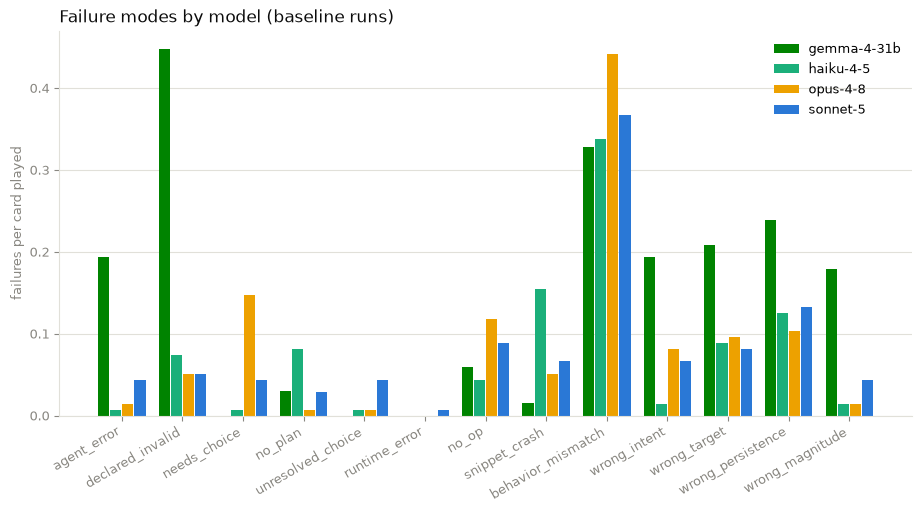

model_short,sonnet-5,haiku-4-5,opus-4-8,gemma-4-31b
failure_buckets,,,,
agent_error,6,1,2,13
declared_invalid,7,10,7,30
needs_choice,6,1,20,0
no_plan,4,11,1,2
unresolved_choice,6,1,1,0
runtime_error,1,0,0,0
no_op,12,6,16,4
snippet_crash,9,21,7,1
behavior_mismatch,50,46,60,22



▶ ANSWER: top failure modes overall: behavior_mismatch (178 rows); wrong_persistence (65 rows); declared_invalid (54 rows)


In [13]:
counts = analysis.bucket_counts(base_rows, by="model_short")
counts = counts[[m for m in MODEL_ORDER if m in counts.columns]]
per_run_cards = base_rows.groupby("model_short").size()
share = counts.div(per_run_cards, axis=1)  # buckets per card, comparable across models

fig, ax = plt.subplots(figsize=(11, 5))
series = [(m, MODEL_COLORS[m], share[m].tolist()) for m in share.columns]
grouped_bars(ax, share.index.tolist(), series)
ax.set_xticklabels(share.index, rotation=30, ha="right")
ax.set_ylabel("failures per card played", color=MUTED, fontsize=9)
ax.set_title("Failure modes by model (baseline runs)", color=INK, fontsize=12, loc="left")
ax.legend(frameon=False, fontsize=9)
plt.show()

display(counts)

overall = analysis.bucket_counts(base_rows)["count"]
top3 = overall.sort_values(ascending=False).head(3)
answer("top failure modes overall: " + "; ".join(f"{b} ({c} rows)" for b, c in top3.items()))

In [14]:
# Primary mode (first bucket = root cause) + real examples per bucket
failing = analysis.failing_rows(base_rows)
failing = failing.assign(primary=failing.failure_buckets.str[0])
primary = failing.primary.value_counts()
print(f"{len(failing)} failing rows (quality < {analysis.FAIL_THRESHOLD}) out of {len(base_rows)}\n")
print("Primary (root-cause) failure mode:")
display(primary.to_frame("failing_rows"))

examples = (
    failing.groupby("primary")
    .apply(lambda g: g.nsmallest(2, "quality"), include_groups=False)
    .reset_index(level=0)[["primary", "card_id", "title", "model_short", "quality", "mech_reason", "judge_reason"]]
)
examples["judge_reason"] = examples.judge_reason.str.slice(0, 110)
display(examples.set_index(["primary", "card_id"]))

77 failing rows (quality < 0.5) out of 475

Primary (root-cause) failure mode:


,failing_rows
primary,
declared_invalid,31
agent_error,22
no_plan,17
behavior_mismatch,4
unresolved_choice,2
no_op,1


title  model_short   quality                                           mech_reason  \
primary           card_id                                                                                                                 
agent_error       eval-019                   Victory Bonus  gemma-4-31b  0.000000                          no resolution_plan in output   
                  seed-filler-006     Point at the Ceiling     opus-4-8  0.100000                          no resolution_plan in output   
behavior_mismatch eval-004          Universal Basic Points     opus-4-8  0.471429                                                         
                  eval-005                         Skip It     opus-4-8  0.471429                                                         
declared_invalid  eval-025             One Does Not Simply  gemma-4-31b  0.000000                          no resolution_plan in output   
                  eval-023         Do Your Best Impression  gemma-4-31b  0.000000                          no resolution_plan in output   
no_op             seed-filler-020         Free Real Estate    haiku-4-5  0.142857                     no mechanical ops emitted (no-op)   
no_plan           seed-filler-011                Time Warp    haiku-4-5  0.000000                          no resolution_plan in output   
                  seed-filler-023            Groundhog Day    haiku-4-5  0.000000                          no resolution_plan in output   
unresolved_choice eval-012                    Burn It Down    haiku-4-5  0.442857  CardTarget 'chosen_card' requires ctx.chosen_card_id   
                  eval-012                    Burn It Down     sonnet-5  0.457143  CardTarget 'chosen_card' requires ctx.chosen_card_id   

                                                                                                                judge_reason  
primary           card_id                                                                                                     
agent_error       eval-019         The generated effect summary is an invalid/malformed output (truncated code snippet wi...  
                  seed-filler-006  The generated output is an invalid/truncated snippet that never completes the logic (n...  
behavior_mismatch eval-004         The generated effect only gives points to self instead of all players, missing the "ev...  
                  eval-005         The card targets the player to the left, but the generated effect applies skip_turn to...  
declared_invalid  eval-025         The generated summary rejected the card as invalid instead of interpreting the actual ...  
                  eval-023         The generated output is a non-functional, flippant comment that fails to encode any ac...  
no_op             seed-filler-020  The generated effect is a no-op that fails to implement the card at all, citing an eng...  
no_plan           seed-filler-011  The generated summary is not an interpretation of the card's mechanical effect at all;...  
                  seed-filler-023  The generated summary declares the card a no-op, entirely missing the actual effect of...  
unresolved_choice eval-012         The generated summary correctly captures the core effect of destroying a chosen card i...  
                  eval-012         The generated effect correctly identifies the core action (destroy a chosen card in pl...

### LLM clustering of the judge's critiques (optional, costs money)

The buckets say *what* broke; the judge's free-text reasons say *what the model misread*.
This cell hands every failing row's critique to an LLM and asks for recurring themes with
counts, example cards, and a suggested fix each. Flip the flag to run it
(needs `LLM_API_KEY` / `LLM_BASE_URL`, same gateway as the harness).

In [15]:
RUN_LLM_CLUSTERING = False  # flip to True to spend ~1 judge-sized call

if RUN_LLM_CLUSTERING:
    import json
    from agent.llm import get_chat_model

    evidence = [
        {
            "card": f"{r.card_id} {r.title}",
            "model": r.model_short,
            "buckets": r.failure_buckets,
            "judge": r.judge_reason[:250],
            "mech": r.mech_reason[:120],
        }
        for r in failing.itertuples()
    ]
    prompt = (
        "You are analyzing failures of an LLM game-master that turns card text into executable "
        "game effects. Below are judge critiques and mechanical errors for every failing card.\n"
        "Cluster them into 4-8 recurring failure themes. For each theme give: a name, the count, "
        "3 example cards, and one concrete fix (prompt change, tool change, or DSL change). "
        "Order by count. End with the single highest-leverage fix overall. Respond in markdown.\n\n"
        + json.dumps(evidence, ensure_ascii=False)
    )
    llm = get_chat_model(temperature=0)
    from IPython.display import Markdown

    display(Markdown(llm.invoke(prompt).content))
else:
    print("skipped — set RUN_LLM_CLUSTERING = True to cluster the judge critiques")

skipped — set RUN_LLM_CLUSTERING = True to cluster the judge critiques


## Q10 — Does the BM25+RRF hybrid retriever beat dense `card_rag`?

Task 6's advanced-retrieval deliverable: `card_rag_hybrid`
(`agent.rag.retrievers.hybrid_retriever`) fuses dense (cosine) search with a BM25
keyword pass over the same card corpus via Reciprocal Rank Fusion. The A/B swaps
**only** which card-RAG tool is in `enabled_tools` — same model, benchmark, and
tool-call cap otherwise (`runner.EvalConfig.enabled_tools`, see `scripts/evals.ipynb`).

Benchmark choice matters: `eval_hard` is where Q5/Q7 run, but as the next cell shows,
the agent barely calls card-RAG there at all, so retrieval quality can't move those
numbers. `seed` (69 cards — real precedent overlap in the corpus) is where the
comparison is actually live, and it's where the arms below were run.

In [16]:
from collections import Counter


def tool_totals(run_key):
    totals = Counter()
    for per_tool in rows.loc[rows.run == run_key, "per_tool"]:
        totals.update(per_tool)
    return totals


def rag_tool_calls(run_key):
    totals = tool_totals(run_key)
    return pd.Series(
        {"card_rag_calls": totals.get("card_rag", 0), "card_rag_hybrid_calls": totals.get("card_rag_hybrid", 0)}
    )


def has_tool(enabled_tools, name):
    return isinstance(enabled_tools, str) and name in enabled_tools.split("+")


# eval_hard: how often is card-RAG even called there, regardless of variant?
hard_rag = runs[
    (runs.benchmark == "eval_hard") & (runs.model_short == "haiku-4-5") & (runs.max_tool_calls == 12)
].copy()
hard_rag = hard_rag.join(hard_rag.run.apply(rag_tool_calls))
display(hard_rag[["label", "enabled_tools", "cases", "card_rag_calls", "card_rag_hybrid_calls", "quality"]].round(3))

total_hard_rag_calls = int(hard_rag.card_rag_calls.sum() + hard_rag.card_rag_hybrid_calls.sum())
total_hard_cards = int(hard_rag.cases.sum())

# seed: the A/B arms — dense card_rag vs the two card_rag_hybrid attempts
seed_rag = runs[(runs.benchmark == "seed") & (runs.model_short == "haiku-4-5") & (runs.max_tool_calls == 12)].copy()
seed_rag = seed_rag.join(seed_rag.run.apply(rag_tool_calls))
seed_rag["dense_enabled"] = seed_rag.enabled_tools.apply(lambda et: has_tool(et, "card_rag"))
seed_rag["hybrid_enabled"] = seed_rag.enabled_tools.apply(lambda et: has_tool(et, "card_rag_hybrid"))
seed_rag = seed_rag.sort_values("timestamp")
display(seed_rag[["label", "cases", "card_rag_calls", "card_rag_hybrid_calls", "quality", "mean_cost_usd"]].round(3))

answer(
    f"eval_hard: card-RAG (either variant) is called {total_hard_rag_calls} times across "
    f"{len(hard_rag)} runs / {total_hard_cards} card-rows — too rare there to test retrieval quality."
)

,label,enabled_tools,cases,card_rag_calls,card_rag_hybrid_calls,quality
11,haiku - eval_hard - maxtools=12,NaN,25,3,0,0.814
14,haiku - eval_hard - maxtools=12 - dry_run_effect+read_game_state,dry_run_effect+read_game_state,25,0,0,0.533
15,haiku - eval_hard - maxtools=12 - dry_run_effect+read_game_state,dry_run_effect+read_engine_methods+read_game_state,25,0,0,0.738
17,haiku - eval_hard - maxtools=12 - hybrid rag,card_rag_hybrid+dry_run_effect+game_rules+mtg_lookup+read_engine_methods+read_game_his...,25,0,0,0.801


,label,cases,card_rag_calls,card_rag_hybrid_calls,quality,mean_cost_usd
18,haiku - seed - maxtools=12 - dense rag (baseline arm),69,15,0,0.660,0.035
19,haiku - seed - maxtools=12 - hybrid rag,69,0,0,0.612,0.034
20,haiku - seed - maxtools=12 - hybrid rag v2 (purpose-led tool description),69,0,19,0.676,0.033



▶ ANSWER: eval_hard: card-RAG (either variant) is called 3 times across 4 runs / 100 card-rows — too rare there to test retrieval quality.


,dense (card_rag),hybrid (card_rag_hybrid),delta
intent_match,0.622,0.627,0.005
target_accuracy,0.713,0.700,-0.013
persistence_accuracy,0.771,0.830,0.059
magnitude_sign,0.780,0.816,0.036
dsl_validity,0.754,0.754,0.000
sandbox_behavior,0.355,0.370,0.014
executability,0.739,0.739,0.000
did_something,0.638,0.652,0.014
invalid_rate,0.145,0.174,0.029
mean_tool_calls,4.899,4.652,-0.246


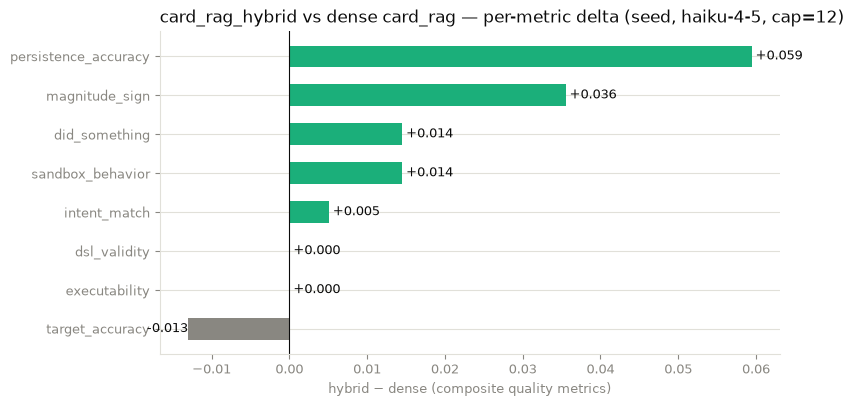


▶ ANSWER: tool-call totals: card_rag 15 calls; card_rag_hybrid 0 calls with the mechanism-led tool description (‘semantic similarity combined with keyword matching’) → 19 calls after rewriting it to lead with retrieval PURPOSE instead — adoption is what moved, not the retriever. Per-metric: persistence_accuracy +0.059 and magnitude_sign +0.036 are the standout lifts; target_accuracy -0.013 is the biggest regression, everything else within noise. Cost: $0.033/card vs $0.035/card (+5%). n=1 sample per card — read deltas smaller than ~0.03–0.05 as noise, not signal; rerun with n_samples≥3 (bead sit) before treating this as final.


In [17]:
# dense_enabled selects exactly one arm; hybrid_enabled selects two (the tool-description
# fix landed between them) — pick by adoption (calls), not by run order, so this stays
# correct if more hybrid attempts are added later.
dense_arm = seed_rag[seed_rag.dense_enabled].iloc[0]
hybrid_attempts = seed_rag[seed_rag.hybrid_enabled].sort_values("card_rag_hybrid_calls")
first_hybrid = hybrid_attempts.iloc[0]  # lowest adoption — the original tool description
best_hybrid = hybrid_attempts.iloc[-1]  # highest adoption — after the description fix

metric_cols = [
    "intent_match",
    "target_accuracy",
    "persistence_accuracy",
    "magnitude_sign",
    "dsl_validity",
    "sandbox_behavior",
    "executability",
    "did_something",
    "invalid_rate",
    "mean_tool_calls",
    "mean_cost_usd",
]
delta = pd.DataFrame(
    {"dense (card_rag)": dense_arm[metric_cols], "hybrid (card_rag_hybrid)": best_hybrid[metric_cols]}
).astype(float)
delta["delta"] = delta["hybrid (card_rag_hybrid)"] - delta["dense (card_rag)"]
display(delta.round(3))

quality_delta = delta["delta"].drop(["invalid_rate", "mean_tool_calls", "mean_cost_usd"]).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.2))
colors = [MODEL_COLORS["haiku-4-5"] if v >= 0 else MUTED for v in quality_delta]
ax.barh(range(len(quality_delta)), quality_delta.values, color=colors, height=0.55)
ax.set_yticks(range(len(quality_delta)))
ax.set_yticklabels(quality_delta.index)
ax.invert_yaxis()
ax.axvline(0, color=INK, linewidth=0.8)
for i, v in enumerate(quality_delta.values):
    ax.text(v, i, f" {v:+.3f}", va="center", ha="left" if v >= 0 else "right", color=INK, fontsize=9)
ax.set_xlabel("hybrid − dense (composite quality metrics)", color=MUTED, fontsize=9)
ax.set_title(
    "card_rag_hybrid vs dense card_rag — per-metric delta (seed, haiku-4-5, cap=12)", color=INK, fontsize=12, loc="left"
)
style(ax)
plt.show()

cost_pct = (dense_arm.mean_cost_usd - best_hybrid.mean_cost_usd) / dense_arm.mean_cost_usd
answer(
    f"tool-call totals: card_rag {int(dense_arm.card_rag_calls)} calls; card_rag_hybrid "
    f"{int(first_hybrid.card_rag_hybrid_calls)} calls with the mechanism-led tool description "
    f"(‘semantic similarity combined with keyword matching’) → {int(best_hybrid.card_rag_hybrid_calls)} calls "
    f"after rewriting it to lead with retrieval PURPOSE instead — adoption is what moved, not the retriever. "
    f"Per-metric: {quality_delta.index[0]} {quality_delta.iloc[0]:+.3f} and {quality_delta.index[1]} "
    f"{quality_delta.iloc[1]:+.3f} are the standout lifts; {quality_delta.index[-1]} {quality_delta.iloc[-1]:+.3f} "
    f"is the biggest regression, everything else within noise. Cost: ${best_hybrid.mean_cost_usd:.3f}/card vs "
    f"${dense_arm.mean_cost_usd:.3f}/card ({cost_pct:+.0%}). n=1 sample per card — read deltas smaller than "
    f"~0.03–0.05 as noise, not signal; rerun with n_samples≥3 (bead sit) before treating this as final."
)

## Conclusions

Everything above, restated by the data (recomputed live, so it stays honest after new runs):

In [18]:
lines = [
    f"1. Most accurate: {ranked.index[0]} ({ranked.iloc[0]:.3f} composite on {common_benches}).",
    f"2. Cheapest: {cost.index[0]} (${cost.mean_cost_usd.iloc[0]:.3f}/card); "
    f"most expensive: {cost.index[-1]} (${cost.mean_cost_usd.iloc[-1]:.3f}/card).",
    f"3. Fastest: {lat.index[0]} (p50 {lat.p50_latency_ms.iloc[0] / 1000:.0f}s/card).",
    f"4. Best overall (rank-sum of quality/cost/speed): {perf.index[0]}; frontier: {frontier}.",
    f"5. max_tool_calls: {rec} (cap=6 measurably hurts; caps ≥{rec} differ by less than the "
    f"~{noise:.2f} noise floor — confirm with n_samples≥3).",
    f"6. eval_hard composite is {hard_delta:+.3f} vs eval (not harder overall); the difficulty shows in "
    f"{biggest} (−{drop.iloc[0]:.3f}). seed carries the RAG answer-key caveat.",
    "7. dry_run_effect dominates usage; both ablations lose quality vs the full toolbox — see Q7 deltas.",
    f"8. {len(universal)} cards fail across ≥75% of runs (card problems, not model problems): "
    f"{', '.join(universal.index)}.",
    "9. Top failure modes: " + "; ".join(f"{b} ({c})" for b, c in top3.items()) + ".",
    f"10. card_rag_hybrid vs dense card_rag (seed, haiku-4-5, cap=12): {quality_delta.index[0]} "
    f"{quality_delta.iloc[0]:+.3f}, {quality_delta.index[1]} {quality_delta.iloc[1]:+.3f}, cost {cost_pct:+.0%} "
    f"— but the finding that mattered was tool ADOPTION: {int(first_hybrid.card_rag_hybrid_calls)} calls "
    f"→ {int(best_hybrid.card_rag_hybrid_calls)} calls after rewriting the tool description "
    f"(n=1, confirm with n_samples≥3).",
]
print("\n".join(lines))

1. Most accurate: sonnet-5 (0.845 composite on ['eval', 'eval_hard']).
2. Cheapest: gemma-4-31b ($0.006/card); most expensive: sonnet-5 ($0.188/card).
3. Fastest: haiku-4-5 (p50 10s/card).
4. Best overall (rank-sum of quality/cost/speed): haiku-4-5; frontier: ['gemma-4-31b', 'haiku-4-5', 'opus-4-8', 'sonnet-5'].
5. max_tool_calls: 12 (cap=6 measurably hurts; caps ≥12 differ by less than the ~0.09 noise floor — confirm with n_samples≥3).
6. eval_hard composite is +0.022 vs eval (not harder overall); the difficulty shows in did_something (−0.136). seed carries the RAG answer-key caveat.
7. dry_run_effect dominates usage; both ablations lose quality vs the full toolbox — see Q7 deltas.
8. 6 cards fail across ≥75% of runs (card problems, not model problems): seed-filler-011, hard-014, eval-041, eval-027, eval-028, eval-012.
9. Top failure modes: behavior_mismatch (178); wrong_persistence (65); declared_invalid (54).
10. card_rag_hybrid vs dense card_rag (seed, haiku-4-5, cap=12): persisten